# FEMA NFIP Flood Insurance - Exploratory Analysis

**Data Sources:**
- `fema_nfip_policies_nj`: 630 rows - Active flood insurance policies by zip code/community
- `fema_nfip_claims_nj`: 2,193 rows - Historical flood insurance claims

**Objectives:**
1. Understand flood insurance coverage across NJ
2. Analyze claim patterns and frequencies
3. Calculate loss ratios and financial exposure
4. Identify high-risk communities
5. Compare coastal vs inland flood risk

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to database
db_path = Path('../data/db/nj_pipeline.duckdb')
conn = duckdb.connect(str(db_path), read_only=True)
print(f"Connected to: {db_path}")

Connected to: ../data/db/nj_pipeline.duckdb


## 1. Data Overview

In [2]:
# Schema information
print("=" * 60)
print("FEMA NFIP POLICIES SCHEMA")
print("=" * 60)
display(conn.execute("DESCRIBE fema_nfip_policies_nj").df())

print("\n" + "=" * 60)
print("FEMA NFIP CLAIMS SCHEMA")
print("=" * 60)
display(conn.execute("DESCRIBE fema_nfip_claims_nj").df())

FEMA NFIP POLICIES SCHEMA


,column_name,column_type,null,key,default,extra
0,zip_code,VARCHAR,YES,None,None,None
1,policy_count,BIGINT,YES,None,None,None
2,total_building_coverage_usd,BIGINT,YES,None,None,None
3,total_contents_coverage_usd,BIGINT,YES,None,None,None
4,total_premium_usd,BIGINT,YES,None,None,None
5,avg_building_coverage_usd,DOUBLE,YES,None,None,None
6,pct_high_risk_flood_zone,DOUBLE,YES,None,None,None



FEMA NFIP CLAIMS SCHEMA


,column_name,column_type,null,key,default,extra
0,zip_code,VARCHAR,YES,None,None,None
1,year_of_loss,BIGINT,YES,None,None,None
2,total_building_claim_usd,DOUBLE,YES,None,None,None
3,total_contents_claim_usd,DOUBLE,YES,None,None,None
4,claim_count,BIGINT,YES,None,None,None


In [3]:
# Sample data
print("\nSample Policy Data:")
display(conn.execute("""
    SELECT * FROM fema_nfip_policies_nj LIMIT 5
""").df())

print("\nSample Claims Data:")
display(conn.execute("""
    SELECT * FROM fema_nfip_claims_nj LIMIT 5
""").df())


Sample Policy Data:


,zip_code,policy_count,total_building_coverage_usd,total_contents_coverage_usd,total_premium_usd,avg_building_coverage_usd,pct_high_risk_flood_zone
0,07001,175,42629900,11312600,187071,243599.428571,46.285714
1,07002,628,144471200,40122200,487632,275708.396947,26.335878
2,07003,936,212502000,16027500,1803659,247671.328671,82.400932
3,07004,2266,571691100,117014500,3976043,252625.320371,80.203270
4,07005,71,18046200,6573600,61464,254171.830986,1.408451



Sample Claims Data:


,zip_code,year_of_loss,total_building_claim_usd,total_contents_claim_usd,claim_count
0,07001,2011,9402.83,0.0,1
1,07002,1995,0.00,0.0,1
2,07002,2018,0.00,0.0,1
3,07002,2020,6026.07,0.0,1
4,07002,2021,205431.83,0.0,2


## 2. Policy Coverage Analysis

In [4]:
# Overall policy statistics
policy_stats = conn.execute("""
    SELECT
        COUNT(*) as num_records,
        SUM(COALESCE(policy_count, 0)) as total_policies,
        SUM(COALESCE(total_building_coverage_usd, 0) + COALESCE(total_contents_coverage_usd, 0)) as total_coverage,
        SUM(COALESCE(total_premium_usd, 0)) as total_premiums,
        COUNT(DISTINCT zip_code) as num_zipcodes
    FROM fema_nfip_policies_nj
""").df()

print("\nNFIP Policy Statistics:")
print(f"  Total policies: {policy_stats['total_policies'].iloc[0]:,}")
print(f"  Total coverage: ${policy_stats['total_coverage'].iloc[0]:,.0f}")
print(f"  Total annual premiums: ${policy_stats['total_premiums'].iloc[0]:,.0f}")
print(f"  Number of zip codes: {policy_stats['num_zipcodes'].iloc[0]}")
print(f"  Avg premium per policy: ${policy_stats['total_premiums'].iloc[0] / policy_stats['total_policies'].iloc[0]:,.2f}")
print(f"  Avg coverage per policy: ${policy_stats['total_coverage'].iloc[0] / policy_stats['total_policies'].iloc[0]:,.0f}")


NFIP Policy Statistics:
  Total policies: 468,327.0
  Total coverage: $119,154,193,500
  Total annual premiums: $443,663,967
  Number of zip codes: 630
  Avg premium per policy: $947.34
  Avg coverage per policy: $254,425


In [5]:
# Policies by zip code
policies_by_zip = conn.execute("""
    SELECT
        zip_code,
        SUM(policy_count) as total_policies,
        SUM((total_building_coverage_usd + total_contents_coverage_usd)) as total_coverage,
        SUM(total_premium_usd) as total_premiums,
        ROUND(SUM(total_premium_usd) / SUM(policy_count), 2) as avg_premium,
        ROUND(SUM((total_building_coverage_usd + total_contents_coverage_usd)) / SUM(policy_count), 0) as avg_coverage
    FROM fema_nfip_policies_nj
    GROUP BY zip_code
    ORDER BY total_policies DESC
""").df()

print("\nPolicies by Zip Code:")
display(policies_by_zip)


Policies by Zip Code:


,zip_code,total_policies,total_coverage,total_premiums,avg_premium,avg_coverage
0,08260,31641.0,6.794538e+09,21708144.0,686.08,214738.0
1,08226,29004.0,8.410953e+09,21523604.0,742.09,289993.0
2,08008,27290.0,7.789456e+09,28627242.0,1049.00,285433.0
3,07030,18236.0,4.249613e+09,13687278.0,750.56,233034.0
4,08401,15799.0,2.867142e+09,13461536.0,852.05,181476.0
...,...,...,...,...,...,...
625,08470,1.0,3.123000e+05,657.0,657.00,312300.0
626,07820,1.0,3.500000e+05,438.0,438.00,350000.0
627,08231,1.0,3.140000e+04,308.0,308.00,31400.0
628,07096,1.0,1.000000e+06,8598.0,8598.00,1000000.0


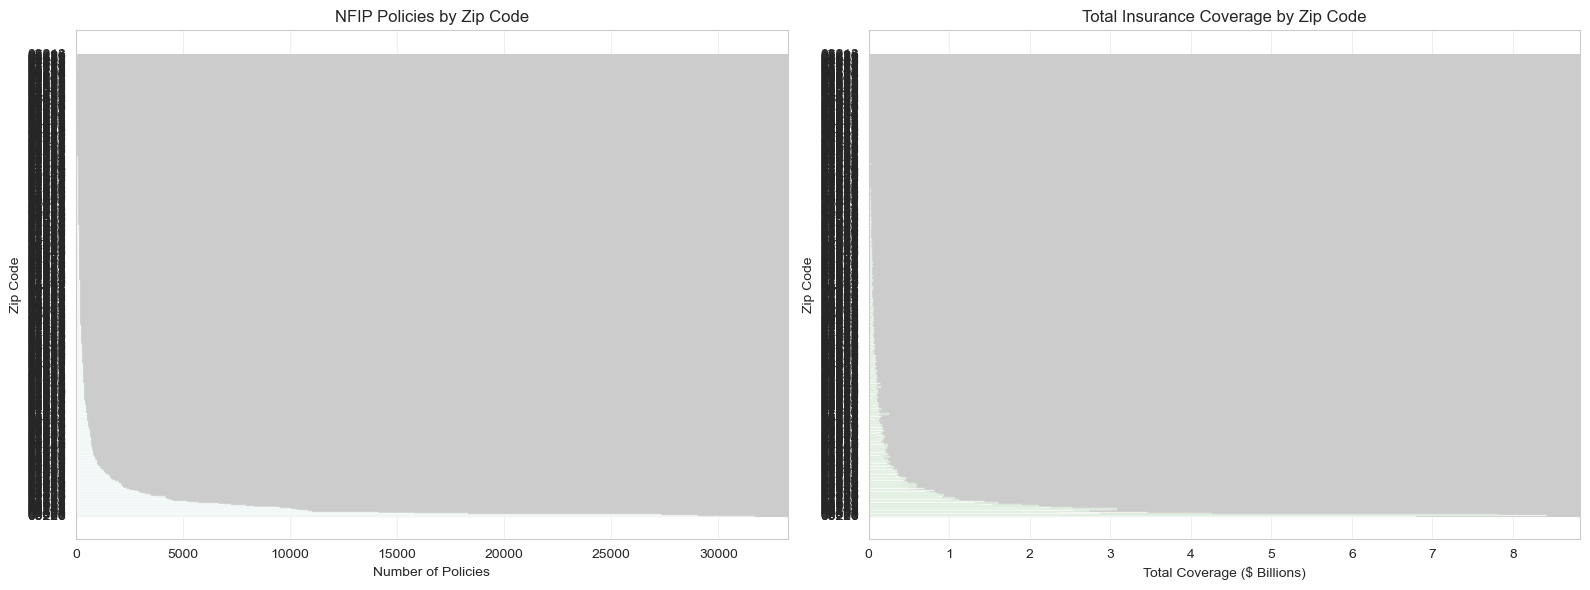

In [6]:
# Visualize policies by zip code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Policy count
axes[0].barh(policies_by_zip['zip_code'].astype(str), policies_by_zip['total_policies'], alpha=0.7)
axes[0].set_xlabel('Number of Policies')
axes[0].set_ylabel('Zip Code')
axes[0].set_title('NFIP Policies by Zip Code')
axes[0].grid(axis='x', alpha=0.3)

# Total coverage
axes[1].barh(policies_by_zip['zip_code'].astype(str), policies_by_zip['total_coverage'] / 1e9,
             alpha=0.7, color='green')
axes[1].set_xlabel('Total Coverage ($ Billions)')
axes[1].set_ylabel('Zip Code')
axes[1].set_title('Total Insurance Coverage by Zip Code')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Claims Analysis

In [7]:
# Overall claims statistics
claims_stats = conn.execute("""
    SELECT
        COUNT(*) as num_records,
        SUM(total_claim_count) as total_claims,
        SUM(total_amount_paid) as total_paid,
        SUM(building_damage_amount) as total_building_damage,
        SUM(contents_damage_amount) as total_contents_damage,
        COUNT(DISTINCT zip_code) as num_zipcodes
    FROM fema_nfip_claims_nj
""").df()

print("\nNFIP Claims Statistics:")
print(f"  Total claims: {claims_stats['total_claims'].iloc[0]:,}")
print(f"  Total amount paid: ${claims_stats['total_paid'].iloc[0]:,.0f}")
print(f"  Building damage: ${claims_stats['total_building_damage'].iloc[0]:,.0f}")
print(f"  Contents damage: ${claims_stats['total_contents_damage'].iloc[0]:,.0f}")
print(f"  Avg payout per claim: ${claims_stats['total_paid'].iloc[0] / claims_stats['total_claims'].iloc[0]:,.2f}")

BinderException: Binder Error: Referenced column "total_claim_count" not found in FROM clause!
Candidate bindings: "total_contents_claim_usd", "total_building_claim_usd", "claim_count", "year_of_loss"

LINE 4:         SUM(total_claim_count) as total_claims,
                    ^

In [8]:
# Claims by zip code
claims_by_zip = conn.execute("""
    SELECT
        zip_code,
        SUM(total_claim_count) as total_claims,
        SUM(total_amount_paid) as total_paid,
        SUM(building_damage_amount) as building_damage,
        SUM(contents_damage_amount) as contents_damage,
        ROUND(SUM(total_amount_paid) / SUM(total_claim_count), 0) as avg_payout
    FROM fema_nfip_claims_nj
    GROUP BY zip_code
    ORDER BY total_claims DESC
""").df()

print("\nClaims by Zip Code:")
display(claims_by_zip)

BinderException: Binder Error: Referenced column "total_claim_count" not found in FROM clause!
Candidate bindings: "total_contents_claim_usd", "total_building_claim_usd", "claim_count", "year_of_loss"

LINE 4:         SUM(total_claim_count) as total_claims,
                    ^

In [ ]:
# Visualize claims by zip code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim count
axes[0].barh(claims_by_zip['zip_code'].astype(str), claims_by_zip['total_claims'],
             alpha=0.7, color='coral')
axes[0].set_xlabel('Number of Claims')
axes[0].set_ylabel('Zip Code')
axes[0].set_title('NFIP Claims by Zip Code')
axes[0].grid(axis='x', alpha=0.3)

# Total paid
axes[1].barh(claims_by_zip['zip_code'].astype(str), claims_by_zip['total_paid'] / 1e6,
             alpha=0.7, color='indianred')
axes[1].set_xlabel('Total Amount Paid ($ Millions)')
axes[1].set_ylabel('Zip Code')
axes[1].set_title('Total Claims Paid by Zip Code')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Loss Ratio Analysis

In [ ]:
# Calculate loss ratio (claims paid / premiums collected)
# Note: This is a simplified calculation - actual loss ratio calculations
# should account for the time period of premiums vs claims

loss_ratio = conn.execute("""
    SELECT
        p.zip_code,
        p.total_policies,
        p.total_coverage,
        p.total_premiums,
        COALESCE(c.total_claims, 0) as total_claims,
        COALESCE(c.total_paid, 0) as total_paid,
        ROUND(COALESCE(c.total_claims, 0) * 100.0 / NULLIF(p.total_policies, 0), 2) as claim_rate_pct,
        ROUND(COALESCE(c.total_paid, 0) / NULLIF(p.total_premiums, 0), 2) as loss_ratio
    FROM
        (SELECT
            zip_code,
            SUM(policy_count) as total_policies,
            SUM((total_building_coverage_usd + total_contents_coverage_usd)) as total_coverage,
            SUM(total_premium_usd) as total_premiums
         FROM fema_nfip_policies_nj
         GROUP BY zip_code) p
    LEFT JOIN
        (SELECT
            zip_code,
            SUM(total_claim_count) as total_claims,
            SUM(total_amount_paid) as total_paid
         FROM fema_nfip_claims_nj
         GROUP BY zip_code) c
    ON p.zip_code = c.zip_code
    ORDER BY loss_ratio DESC NULLS LAST
""").df()

print("\nLoss Ratio by Zip Code:")
print("(Loss Ratio = Total Claims Paid / Total Annual Premiums)")
print("Note: This is simplified - actual calculations need multi-year data\n")
display(loss_ratio)

In [ ]:
# Visualize loss ratio
fig, ax = plt.subplots(figsize=(12, 6))
loss_ratio_sorted = loss_ratio.sort_values('loss_ratio')
colors = ['red' if x > 1 else 'green' for x in loss_ratio_sorted['loss_ratio']]
ax.barh(loss_ratio_sorted['zip_code'].astype(str), loss_ratio_sorted['loss_ratio'], alpha=0.7, color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', label='Break-even (1.0)')
ax.set_xlabel('Loss Ratio (Claims Paid / Premiums)')
ax.set_ylabel('Zip Code')
ax.set_title('Loss Ratio by Zip Code\n(Red = Losses exceed premiums, Green = Premiums exceed losses)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nZip codes with loss ratio > 1 (losses exceed premiums): {len(loss_ratio[loss_ratio['loss_ratio'] > 1])}")
print(f"Zip codes with loss ratio < 1 (premiums exceed losses): {len(loss_ratio[loss_ratio['loss_ratio'] < 1])}")

## 5. Flood Risk Assessment

In [ ]:
# Claim frequency analysis
print("\nFlood Risk Metrics by Zip Code:")
print("\nClaim Rate: % of policies that have filed claims")
print("Loss Ratio: Total paid / Annual premiums")
print("Avg Payout: Average claim payout amount\n")

risk_metrics = loss_ratio[['zip_code', 'total_policies', 'total_claims',
                           'claim_rate_pct', 'loss_ratio']].copy()
risk_metrics['avg_claim_payout'] = (loss_ratio['total_paid'] /
                                     loss_ratio['total_claims']).round(0)

display(risk_metrics.sort_values('claim_rate_pct', ascending=False))

In [ ]:
# Scatter plot: Claim rate vs Loss ratio
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(risk_metrics['claim_rate_pct'],
                     risk_metrics['loss_ratio'],
                     s=risk_metrics['total_policies'] / 100,  # Size by policy count
                     alpha=0.6, c=risk_metrics['loss_ratio'],
                     cmap='RdYlGn_r')

# Add zip code labels
for idx, row in risk_metrics.iterrows():
    ax.annotate(str(row['zip_code']),
                (row['claim_rate_pct'], row['loss_ratio']),
                fontsize=9, ha='center')

ax.set_xlabel('Claim Rate (% of Policies with Claims)')
ax.set_ylabel('Loss Ratio (Claims Paid / Premiums)')
ax.set_title('Flood Risk Profile by Zip Code\n(Bubble size = Number of policies)')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax.grid(True, alpha=0.3)
ax.legend()

plt.colorbar(scatter, ax=ax, label='Loss Ratio')
plt.tight_layout()
plt.show()

## 6. Building vs Contents Damage

In [ ]:
# Breakdown of damage types
damage_breakdown = conn.execute("""
    SELECT
        zip_code,
        SUM(building_damage_amount) as building_damage,
        SUM(contents_damage_amount) as contents_damage,
        SUM(total_amount_paid) as total_damage,
        ROUND(SUM(building_damage_amount) * 100.0 /
              NULLIF(SUM(total_amount_paid), 0), 1) as pct_building,
        ROUND(SUM(contents_damage_amount) * 100.0 /
              NULLIF(SUM(total_amount_paid), 0), 1) as pct_contents
    FROM fema_nfip_claims_nj
    GROUP BY zip_code
    ORDER BY total_damage DESC
""").df()

print("\nBuilding vs Contents Damage by Zip Code:")
display(damage_breakdown)

In [ ]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

damage_breakdown_sorted = damage_breakdown.sort_values('total_damage')
zips = damage_breakdown_sorted['zip_code'].astype(str)
building = damage_breakdown_sorted['building_damage'] / 1e6
contents = damage_breakdown_sorted['contents_damage'] / 1e6

ax.barh(zips, building, label='Building Damage', alpha=0.8)
ax.barh(zips, contents, left=building, label='Contents Damage', alpha=0.8)

ax.set_xlabel('Total Damage ($ Millions)')
ax.set_ylabel('Zip Code')
ax.set_title('Building vs Contents Damage by Zip Code')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOverall breakdown:")
total_building = damage_breakdown['building_damage'].sum()
total_contents = damage_breakdown['contents_damage'].sum()
total_all = total_building + total_contents
print(f"  Building damage: ${total_building:,.0f} ({total_building/total_all*100:.1f}%)")
print(f"  Contents damage: ${total_contents:,.0f} ({total_contents/total_all*100:.1f}%)")

## 7. Coverage Adequacy

In [ ]:
# Compare average coverage to average claim payout
coverage_adequacy = conn.execute("""
    SELECT
        p.zip_code,
        ROUND(p.total_coverage / p.total_policies, 0) as avg_coverage_per_policy,
        ROUND(COALESCE(c.total_paid / NULLIF(c.total_claims, 0), 0), 0) as avg_payout_per_claim,
        p.total_policies,
        COALESCE(c.total_claims, 0) as total_claims
    FROM
        (SELECT
            zip_code,
            SUM(policy_count) as total_policies,
            SUM((total_building_coverage_usd + total_contents_coverage_usd)) as total_coverage
         FROM fema_nfip_policies_nj
         GROUP BY zip_code) p
    LEFT JOIN
        (SELECT
            zip_code,
            SUM(total_claim_count) as total_claims,
            SUM(total_amount_paid) as total_paid
         FROM fema_nfip_claims_nj
         GROUP BY zip_code) c
    ON p.zip_code = c.zip_code
    ORDER BY p.zip_code
""").df()

print("\nCoverage Adequacy Analysis:")
print("Comparing average policy coverage to average claim payout\n")
display(coverage_adequacy)

In [ ]:
# Visualize coverage vs payout
fig, ax = plt.subplots(figsize=(12, 8))

x = coverage_adequacy['avg_coverage_per_policy'] / 1000  # In thousands
y = coverage_adequacy['avg_payout_per_claim'] / 1000  # In thousands

ax.scatter(x, y, s=100, alpha=0.6)

for idx, row in coverage_adequacy.iterrows():
    ax.annotate(str(row['zip_code']),
                (row['avg_coverage_per_policy']/1000, row['avg_payout_per_claim']/1000),
                fontsize=10, ha='center')

# Add diagonal line (coverage = payout)
max_val = max(x.max(), y.max())
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Coverage = Avg Payout')

ax.set_xlabel('Average Coverage per Policy ($1000s)')
ax.set_ylabel('Average Payout per Claim ($1000s)')
ax.set_title('Coverage Adequacy: Policy Coverage vs Claim Payouts')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [ ]:
print("="*70)
print("KEY FINDINGS - FEMA NFIP FLOOD INSURANCE")
print("="*70)

print(f"\n1. COVERAGE")
print(f"   • Total active policies: {policy_stats['total_policies'].iloc[0]:,}")
print(f"   • Total coverage: ${policy_stats['total_coverage'].iloc[0]:,.0f}")
print(f"   • Zip codes covered: {policy_stats['num_zipcodes'].iloc[0]}")
print(f"   • Avg coverage/policy: ${policy_stats['total_coverage'].iloc[0] / policy_stats['total_policies'].iloc[0]:,.0f}")

print(f"\n2. CLAIMS HISTORY")
print(f"   • Total claims: {claims_stats['total_claims'].iloc[0]:,}")
print(f"   • Total paid out: ${claims_stats['total_paid'].iloc[0]:,.0f}")
print(f"   • Avg payout/claim: ${claims_stats['total_paid'].iloc[0] / claims_stats['total_claims'].iloc[0]:,.2f}")
print(f"   • Building damage: {claims_stats['total_building_damage'].iloc[0] / claims_stats['total_paid'].iloc[0] * 100:.1f}% of total")
print(f"   • Contents damage: {claims_stats['total_contents_damage'].iloc[0] / claims_stats['total_paid'].iloc[0] * 100:.1f}% of total")

print(f"\n3. HIGHEST RISK ZIP CODES (by claim rate)")
top_risk = risk_metrics.nlargest(3, 'claim_rate_pct')
for _, row in top_risk.iterrows():
    print(f"   • Zip Code {row['zip_code']}: {row['claim_rate_pct']:.1f}% claim rate, {row['loss_ratio']:.2f} loss ratio")

print(f"\n4. FINANCIAL PERFORMANCE")
avg_loss_ratio = loss_ratio['loss_ratio'].mean()
unprofitable_zips = len(loss_ratio[loss_ratio['loss_ratio'] > 1])
print(f"   • Average loss ratio: {avg_loss_ratio:.2f}")
print(f"   • Zip codes with losses exceeding premiums: {unprofitable_zips}")

print(f"\n5. PREMIUMS")
print(f"   • Total annual premiums: ${policy_stats['total_premiums'].iloc[0]:,.0f}")
print(f"   • Avg premium/policy: ${policy_stats['total_premiums'].iloc[0] / policy_stats['total_policies'].iloc[0]:,.2f}")

print("\n" + "="*70)

In [ ]:
conn.close()
print("\nAnalysis complete. Database connection closed.")